In [2]:
%pip install -q \
    "math-verify[antlr4_13_2]==0.9.0" \
    sympy==1.13.3 \
    pandas==2.2.2 \
    pyarrow==16.1.0 \
    numpy==1.26.4 \
    datasets==2.20.0 \
    azure-ai-ml azure-identity

print("done — RESTART THE KERNEL now (Kernel > Restart Kernel)")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /anaconda/envs/azureml_py310_sdkv2/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
done — RESTART THE KERNEL now (Kernel > Restart Kernel)


In [1]:
import os, sys

ROOT = "/home/azureuser/cloudfiles/code/Users/estherxin0011/verifier-error-budget"
SRC  = os.path.join(ROOT, "src")

assert os.path.isdir(SRC), f"src not found at {SRC} — did you unzip into the right place?"
if SRC not in sys.path:
    sys.path.insert(0, SRC)

os.chdir(ROOT)
print("cwd:", os.getcwd())
print("files:", sorted(os.listdir(SRC)))

import math_verify
print("math_verify OK")

cwd: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget
files: ['.amlignore', '.amlignore.amltmp', 'aggregate.py', 'differential_verify.py', 'normalizers.py', 'prepare_gold.py', 'transforms.py', 'verifiers.py']
math_verify OK


In [1]:
c

ModuleNotFoundError: No module named 'transforms'

In [2]:
import os
import sys

SRC = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget"

if SRC not in sys.path:
    sys.path.insert(0, SRC)

os.chdir(SRC)

import transforms

print(transforms.__file__)
print("transforms:", len(transforms.TRANSFORMS))  # expect 42


ModuleNotFoundError: No module named 'transforms'

In [3]:
import os, sys

SRC = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget"

assert os.path.isdir(SRC), "folder not found: " + SRC
if SRC not in sys.path:
    sys.path.insert(0, SRC)
os.chdir(SRC)

print("cwd :", os.getcwd())
print("py  :", sorted(f for f in os.listdir(SRC) if f.endswith(".py")))

import math_verify
print("math_verify OK")

import transforms
print("transforms file :", transforms.__file__)
print("transforms count:", len(transforms.TRANSFORMS), "(expect 42)")

cwd : /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget
py  : []
math_verify OK


In [1]:
import os, sys, glob, json, subprocess
import pandas as pd

from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

BASE_DIR = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget"

# >>> PASTE YOUR COMPLETED PIPELINE JOB NAME HERE <<<
JOB_NAME = "affable_lamp_mc42d1lyyj"

ml = MLClient(DefaultAzureCredential(),
              "7a8513b6-ada2-4ad1-aee2-687fa5663c82",
              "AIModels",
              "Reinforcementinfra")

os.chdir(BASE_DIR)
print("BASE_DIR :", BASE_DIR)
print("JOB_NAME :", JOB_NAME)
print("status   :", ml.jobs.get(JOB_NAME).status)

BASE_DIR : /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget
JOB_NAME : affable_lamp_mc42d1lyyj
status   : Failed


In [3]:
import glob
import os

# 1. Find the specific child job
child = [
    j
    for j in ml.jobs.list(parent_job_name=JOB_NAME)
    if "differential_verify" in (j.display_name or "")
][0]
print("child:", child.name, child.status)

# 2. Create the target directory for verdicts
VERD = os.path.join(BASE_DIR, "results", JOB_NAME + "_verdicts")
os.makedirs(VERD, exist_ok=True)

# 3. Download the results
ml.jobs.download(name=child.name, output_name="verdicts", download_path=VERD)

# 4. Verify and locate parquet files
pq = glob.glob(os.path.join(VERD, "**", "*.parquet"), recursive=True)
print("parquet files downloaded:", len(pq))
assert pq, "still empty - list what did download below"

VDIR = os.path.dirname(pq[0])
print("verdicts dir:", VDIR)


child: 40aa45b6-14b4-4a3a-87ac-bce669b61101 Completed
parquet files downloaded: 48
verdicts dir: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/affable_lamp_mc42d1lyyj_verdicts/named-outputs/verdicts


In [4]:
AGG = os.path.join(BASE_DIR, "src", "aggregate.py")
if not os.path.exists(AGG):
    AGG = os.path.join(BASE_DIR, "aggregate.py")
assert os.path.exists(AGG), "aggregate.py not found"
print("using:", AGG)

RDIR = os.path.join(BASE_DIR, "results", "report_local")
os.makedirs(RDIR, exist_ok=True)

r = subprocess.run(
    [sys.executable, AGG, "--verdicts_dir", VDIR, "--report_dir", RDIR],
    capture_output=True, text=True)

print("--- stdout (tail) ---")
print(r.stdout[-4000:])
print("--- stderr (tail) ---")
print(r.stderr[-4000:])
print("--- return code:", r.returncode, "---")

using: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/src/aggregate.py
--- stdout (tail) ---
48 shard files
  pass1 0/48
{
  "n_verdicts": 95772,
  "certified_fn_rate": 0.30313957770684996,
  "adversarial_fp_rate": 0.00652627915071354,
  "timeout_rate": 0.0
}

--- stderr (tail) ---

--- return code: 0 ---


In [5]:
summary = json.load(open(os.path.join(RDIR, "summary.json")))
print(json.dumps(summary, indent=2))
print()
print("files produced:")
for f in sorted(os.listdir(RDIR)):
    print("  ", f)

{
  "n_verdicts": 95772,
  "certified_fn_rate": 0.30313957770684996,
  "adversarial_fp_rate": 0.00652627915071354,
  "timeout_rate": 0.0
}

files produced:
   T1_fn_by_stratum_verifier.csv
   T2_error_mass_share.csv
   T3_fp_by_stratum_verifier.csv
   T4_disagreement_matrix.csv
   T5_contract_dependent.csv
   T6_reconciliation.csv
   summary.json


In [6]:
T6 = pd.read_csv(os.path.join(RDIR, "T6_reconciliation.csv"))
display(T6)

,verifier,n,n_true,n_timeout,n_error,self_validation_rate,residual,share_timeout,share_error
0,mathverify_expr,16292,7107,0,0,0.436226,0.563774,0.0,0.000000
1,mathverify_latex,16292,13296,0,0,0.816106,0.183894,0.0,0.000000
2,strip_string,16292,8718,0,0,0.535109,0.464891,0.0,0.000000
3,sympy_cascade,16292,8723,0,7569,0.535416,0.464584,0.0,0.464584


In [7]:
T2 = pd.read_csv(os.path.join(RDIR, "T2_error_mass_share.csv"))
display(T2.head(30))

,verifier,stratum,fn_count,error_mass_share
0,mathverify_expr,S3_boxing,4662,0.507567
1,mathverify_expr,S5_mathmode,2415,0.262929
2,mathverify_expr,S11_text,1269,0.138160
3,mathverify_expr,S6_whitespace,301,0.032771
4,mathverify_expr,S8_scientific,293,0.031900
5,mathverify_expr,S1_frac_dialect,190,0.020686
6,mathverify_expr,S2_frac_decimal,24,0.002613
7,mathverify_expr,S4_delimiters,20,0.002177
8,mathverify_expr,S7_sqrt_exp,8,0.000871
9,mathverify_expr,S10_sets,3,0.000327


In [8]:
T1 = pd.read_csv(os.path.join(RDIR, "T1_fn_by_stratum_verifier.csv"))
display(T1.head(40))

,stratum,verifier,n,fn_rate,timeout_rate,err_rate,ci_lo,ci_hi
0,S8_scientific,mathverify_expr,293,1.000000,0.0,0.000000,9.870584e-01,1.000000
1,S3_boxing,mathverify_expr,4774,0.976540,0.0,0.000000,9.718474e-01,0.980465
2,S1_frac_dialect,mathverify_expr,208,0.913462,0.0,0.000000,8.673667e-01,0.944561
3,S4_delimiters,mathverify_expr,25,0.800000,0.0,0.000000,6.086866e-01,0.911395
4,S5_mathmode,mathverify_expr,3576,0.675336,0.0,0.000000,6.598071e-01,0.690488
5,S10_sets,mathverify_expr,5,0.600000,0.0,0.000000,2.307199e-01,0.882382
6,S11_text,mathverify_expr,2388,0.531407,0.0,0.000000,5.113578e-01,0.551355
7,S7_sqrt_exp,mathverify_expr,26,0.307692,0.0,0.000000,1.650112e-01,0.499886
8,S6_whitespace,mathverify_expr,3628,0.082966,0.0,0.000000,7.442522e-02,0.092389
9,S2_frac_decimal,mathverify_expr,976,0.024590,0.0,0.000000,1.657923e-02,0.036329


In [9]:
T4 = pd.read_csv(os.path.join(RDIR, "T4_disagreement_matrix.csv"), index_col=0)
display(T4.style.format("{:.4f}", na_rep="-"))

,mathverify_expr,mathverify_latex,strip_string,sympy_cascade
mathverify_expr,0.0000,0.4101,0.2534,0.2531
mathverify_latex,0.4101,0.0000,0.3419,0.3416
strip_string,0.2534,0.3419,0.0000,0.0003
sympy_cascade,0.2531,0.3416,0.0003,0.0000


In [10]:
T3 = pd.read_csv(os.path.join(RDIR, "T3_fp_by_stratum_verifier.csv"))
print("T3 - adversarial false positives (should be near zero)")
display(T3)

T5 = pd.read_csv(os.path.join(RDIR, "T5_contract_dependent.csv"))
print("T5 - contract-dependent (spec ambiguity, NOT bugs)")
display(T5)

T3 - adversarial false positives (should be near zero)


,stratum,verifier,n,fp_rate
0,A_append,mathverify_expr,1194,0.000000
1,A_append,mathverify_latex,1194,0.000000
2,A_append,strip_string,1194,0.000000
3,A_append,sympy_cascade,1194,0.000000
4,A_digit,mathverify_expr,687,0.000000
5,A_digit,mathverify_latex,687,0.000000
6,A_digit,strip_string,687,0.000000
7,A_digit,sympy_cascade,687,0.000000
8,A_offset,mathverify_expr,947,0.000000
9,A_offset,mathverify_latex,947,0.000000


T5 - contract-dependent (spec ambiguity, NOT bugs)


,stratum,verifier,n,accept_rate
0,S12_units,mathverify_expr,1904,0.5
1,S12_units,mathverify_latex,1904,1.0
2,S12_units,strip_string,1904,1.0
3,S12_units,sympy_cascade,1904,1.0
4,S13_percent,mathverify_expr,1,0.0
5,S13_percent,mathverify_latex,1,1.0
6,S13_percent,strip_string,1,0.0
7,S13_percent,sympy_cascade,1,0.0


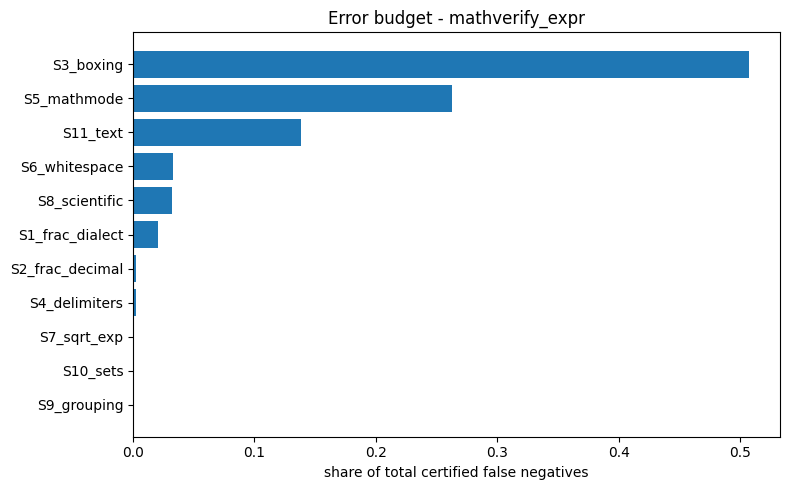

saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_local/fig1_error_budget.png


In [11]:
import matplotlib.pyplot as plt

v = T2.verifier.iloc[0]
d = T2[T2.verifier == v].nlargest(12, "error_mass_share")[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(d.stratum, d.error_mass_share)
ax.set_xlabel("share of total certified false negatives")
ax.set_title("Error budget - " + str(v))
plt.tight_layout()
plt.savefig(os.path.join(RDIR, "fig1_error_budget.png"), dpi=200)
plt.show()
print("saved:", os.path.join(RDIR, "fig1_error_budget.png"))

In [12]:
import os, json, glob
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

L = []
def P(*a):
    s = " ".join(str(x) for x in a)
    L.append(s)
    print(s)

P("=" * 70)
P("VERIFIER ERROR BUDGET - RESULT DIGEST")
P("=" * 70)

# ---- scale ----
P("\n### SCALE")
try:
    man = glob.glob(os.path.join(BASE_DIR, "results", "**", "_manifest.json"),
                    recursive=True)
    if man:
        m = json.load(open(man[0]))
        P("n_golds :", m.get("n_golds"))
        P("n_tasks :", m.get("n_tasks"))
        P("n_shards:", m.get("n_shards"))
    else:
        P("manifest not downloaded (optional)")
except Exception as e:
    P("manifest error:", e)
P("parquet shards:", len(pq))

# ---- summary ----
P("\n### SUMMARY.JSON")
P(json.dumps(json.load(open(os.path.join(RDIR, "summary.json"))), indent=2))

# ---- T6 ----
P("\n### T6 RECONCILIATION (self-validation rate per verifier)")
T6 = pd.read_csv(os.path.join(RDIR, "T6_reconciliation.csv"))
P(T6.to_string(index=False))

# ---- T2 ----
P("\n### T2 ERROR MASS SHARE (top 12 per verifier)")
T2 = pd.read_csv(os.path.join(RDIR, "T2_error_mass_share.csv"))
for v in T2.verifier.unique():
    P("\n-- " + str(v))
    P(T2[T2.verifier == v].nlargest(12, "error_mass_share")
        [["stratum", "fn_count", "error_mass_share"]].to_string(index=False))

# ---- T1 ----
P("\n### T1 FN RATE BY STRATUM x VERIFIER (full)")
T1 = pd.read_csv(os.path.join(RDIR, "T1_fn_by_stratum_verifier.csv"))
P(T1.round(4).to_string(index=False))

# ---- T4 ----
P("\n### T4 CROSS-VERIFIER DISAGREEMENT")
T4 = pd.read_csv(os.path.join(RDIR, "T4_disagreement_matrix.csv"), index_col=0)
P(T4.round(4).to_string())

# ---- T3 ----
P("\n### T3 ADVERSARIAL FALSE POSITIVES")
T3 = pd.read_csv(os.path.join(RDIR, "T3_fp_by_stratum_verifier.csv"))
P(T3.round(4).to_string(index=False))

# ---- T5 ----
P("\n### T5 CONTRACT-DEPENDENT (spec ambiguity, not bugs)")
T5 = pd.read_csv(os.path.join(RDIR, "T5_contract_dependent.csv"))
P(T5.round(4).to_string(index=False))

P("\n" + "=" * 70)
P("END OF DIGEST")
P("=" * 70)

with open(os.path.join(RDIR, "digest.txt"), "w") as f:
    f.write("\n".join(L))
print("\n[saved to " + os.path.join(RDIR, "digest.txt") + "]")

VERIFIER ERROR BUDGET - RESULT DIGEST

### SCALE
manifest not downloaded (optional)
parquet shards: 48

### SUMMARY.JSON
{
  "n_verdicts": 95772,
  "certified_fn_rate": 0.30313957770684996,
  "adversarial_fp_rate": 0.00652627915071354,
  "timeout_rate": 0.0
}

### T6 RECONCILIATION (self-validation rate per verifier)
        verifier     n  n_true  n_timeout  n_error  self_validation_rate  residual  share_timeout  share_error
 mathverify_expr 16292    7107          0        0              0.436226  0.563774            0.0     0.000000
mathverify_latex 16292   13296          0        0              0.816106  0.183894            0.0     0.000000
    strip_string 16292    8718          0        0              0.535109  0.464891            0.0     0.000000
   sympy_cascade 16292    8723          0     7569              0.535416  0.464584            0.0     0.464584

### T2 ERROR MASS SHARE (top 12 per verifier)

-- mathverify_expr
        stratum  fn_count  error_mass_share
      S3_boxing

In [13]:
import pandas as pd

frames = []
for f in pq[:30]:
    d = pd.read_parquet(f, columns=["gold", "pred", "tid", "stratum",
                                    "tclass", "verifier", "verdict"])
    frames.append(d[(d.tclass == "certified_equiv") & (d.verdict == "FALSE")])

fn = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print("certified FN rows sampled:", len(fn))

if len(fn):
    ex = (fn.groupby(["verifier", "stratum", "tid"])
            .head(2)
            .groupby(["verifier", "stratum"])
            .head(3)
            .head(40))
    print(ex[["verifier", "tid", "gold", "pred"]].to_string(index=False))
    ex.to_csv(os.path.join(RDIR, "fn_examples.csv"), index=False)
    print("\n[saved fn_examples.csv]")

certified FN rows sampled: 12352
        verifier               tid                                 gold                                  pred
 mathverify_expr     T10_add_boxed                                  859                           \boxed{859}
    strip_string     T10_add_boxed                                  859                           \boxed{859}
 mathverify_expr      T11_add_fbox                                  859                            \fbox{859}
    strip_string      T11_add_fbox                                  859                            \fbox{859}
 mathverify_expr  T12_double_boxed                                  859                   \boxed{\boxed{859}}
    strip_string  T12_double_boxed                                  859                   \boxed{\boxed{859}}
mathverify_latex  T13_prefix_boxed                                  859            \boxed{0} then \boxed{859}
 mathverify_expr T17_double_dollar                                  859                

In [3]:
import os, sys, glob, json, re, subprocess
import pandas as pd

from azure.ai.ml import MLClient, load_job
from azure.identity import DefaultAzureCredential

BASE_DIR = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget"

SRC = os.path.join(BASE_DIR, "src")
if not os.path.isdir(SRC):
    SRC = BASE_DIR

os.chdir(BASE_DIR)
if SRC not in sys.path:
    sys.path.insert(0, SRC)

ml = MLClient(DefaultAzureCredential(),
              "7a8513b6-ada2-4ad1-aee2-687fa5663c82",
              "AIModels",
              "Reinforcementinfra")

print("BASE_DIR:", BASE_DIR)
print("SRC     :", SRC)
print("files   :", sorted(f for f in os.listdir(SRC) if f.endswith(".py")))

BASE_DIR: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget
SRC     : /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/src
files   : ['aggregate.py', 'differential_verify.py', 'normalizers.py', 'prepare_gold.py', 'transforms.py', 'verifiers.py']


In [5]:
PIPE = os.path.join(BASE_DIR, "pipelines.yml")
y = open(PIPE).read()
y = re.sub(r"--max_golds \d+", "--max_golds 40000", y)
open(PIPE, "w").write(y)

for line in y.splitlines():
    if "max_golds" in line or "code:" in line or "environment:" in line:
        print(line.strip())

environment: azureml:verifier-audit-cpu:2
code: ./src
--max_golds 40000
code: ./src
environment: azureml:verifier-audit-cpu:2
environment: azureml:verifier-audit-cpu:2
code: ./src


In [6]:
full = ml.jobs.create_or_update(load_job(PIPE))
JOB = full.name
print("job name:", JOB)
print("url     :", full.studio_url)

with open(os.path.join(BASE_DIR, "last_job.txt"), "w") as f:
    f.write(JOB)
print("\n[job name saved to last_job.txt]")

Class AutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class AutoDeleteConditionSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseAutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class IntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class ProtectionLevelSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseIntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
pathOnCompute is not a known attribute

job name: dreamy_flag_qksrrzfv2f
url     : https://ml.azure.com/runs/dreamy_flag_qksrrzfv2f?wsid=/subscriptions/7a8513b6-ada2-4ad1-aee2-687fa5663c82/resourcegroups/AIModels/workspaces/Reinforcementinfra&tid=4033a39c-0759-4168-a40c-a9bc796b4f42

[job name saved to last_job.txt]


In [7]:
BASE_DIR = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget"

child = [j for j in ml.jobs.list(parent_job_name=JOB)
         if "differential_verify" in (j.display_name or "")][0]
print("child:", child.name, child.status)

VERD = os.path.join(BASE_DIR, "results", JOB + "_verdicts")
os.makedirs(VERD, exist_ok=True)
ml.jobs.download(name=child.name, output_name="verdicts", download_path=VERD)

pq = glob.glob(os.path.join(VERD, "**", "*.parquet"), recursive=True)
print("parquet shards:", len(pq))
assert pq, "no parquet downloaded"
VDIR = os.path.dirname(pq[0])
print("verdicts dir  :", VDIR)

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
job 16490107-ed93-4502-9496-780baf755642 reuses previous job 25cdc8f0-75c7-4191-a477-54cc6f7e317e, download from the reused job.


child: 16490107-ed93-4502-9496-780baf755642 Completed
parquet shards: 33
verdicts dir  : /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/dreamy_flag_qksrrzfv2f_verdicts/named-outputs/verdicts


In [8]:
AGG = os.path.join(SRC, "aggregate.py")
RDIR = os.path.join(BASE_DIR, "results", "report_40k")
os.makedirs(RDIR, exist_ok=True)

r = subprocess.run([sys.executable, AGG,
                    "--verdicts_dir", VDIR,
                    "--report_dir", RDIR],
                   capture_output=True, text=True)
print(r.stdout[-4000:])
print(r.stderr[-3000:])
print("return code:", r.returncode)

33 shard files
  pass1 0/33
{
  "n_verdicts": 64674,
  "in_contract_n": 19087,
  "in_contract_fn_rate": 0.04049876879551527,
  "in_contract_failure_rate": 0.04049876879551527,
  "out_of_contract_n": 269,
  "adversarial_fp_rate": 0.0,
  "overall_error_rate": 0.0
}


return code: 0


In [9]:
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 300)

L = []
def P(*a):
    s = " ".join(str(x) for x in a)
    L.append(s); print(s)

P("=" * 74)
P("VERIFIER ERROR BUDGET - 40K DIGEST (v3)")
P("=" * 74)

P("\n### SUMMARY")
P(json.dumps(json.load(open(os.path.join(RDIR, "summary.json"))), indent=2))

def show(fn, title, nrows=None):
    p = os.path.join(RDIR, fn)
    if not os.path.exists(p):
        P("\n### " + title + " (missing)"); return None
    df = pd.read_csv(p)
    P("\n### " + title)
    P((df.head(nrows) if nrows else df).round(4).to_string(index=False))
    return df

T6 = show("T6_reconciliation.csv", "T6 RECONCILIATION (in-contract only)")
T1 = show("T1_fn_by_stratum_verifier.csv", "T1 IN-CONTRACT FN + FAILURE RATE")
T2 = show("T2_error_mass_share.csv", "T2 ERROR MASS SHARE")
T3 = show("T3_fp_by_stratum_verifier.csv", "T3 ADVERSARIAL FALSE POSITIVES")
T8 = show("T8_offbyone_by_magnitude.csv", "T8 OFF-BY-ONE FP BY MAGNITUDE")
T7 = show("T7_out_of_contract.csv", "T7 OUT-OF-CONTRACT")
T5 = show("T5_contract_dependent.csv", "T5 CONTRACT-DEPENDENT")

P("\n### T4 CROSS-VERIFIER DISAGREEMENT")
T4 = pd.read_csv(os.path.join(RDIR, "T4_disagreement_matrix.csv"), index_col=0)
P(T4.round(4).to_string())

P("\n" + "=" * 74)
with open(os.path.join(RDIR, "digest_40k.txt"), "w") as f:
    f.write("\n".join(L))
print("\n[saved digest_40k.txt]")

VERIFIER ERROR BUDGET - 40K DIGEST (v3)

### SUMMARY
{
  "n_verdicts": 64674,
  "in_contract_n": 19087,
  "in_contract_fn_rate": 0.04049876879551527,
  "in_contract_failure_rate": 0.04049876879551527,
  "out_of_contract_n": 269,
  "adversarial_fp_rate": 0.0,
  "overall_error_rate": 0.0
}

### T6 RECONCILIATION (in-contract only)
        verifier    n  n_true  n_false  n_timeout  n_error  n_fail  self_validation_rate  residual  share_false  share_timeout  share_error
 mathverify_expr 6188    5777      411          0        0     411                0.9336    0.0664       0.0664            0.0          0.0
mathverify_latex 6452    6184      268          0        0     268                0.9585    0.0415       0.0415            0.0          0.0
    strip_string 6447    6353       94          0        0      94                0.9854    0.0146       0.0146            0.0          0.0

### T1 IN-CONTRACT FN + FAILURE RATE
        stratum         verifier    n  n_false  n_fail  fn_rate  failur

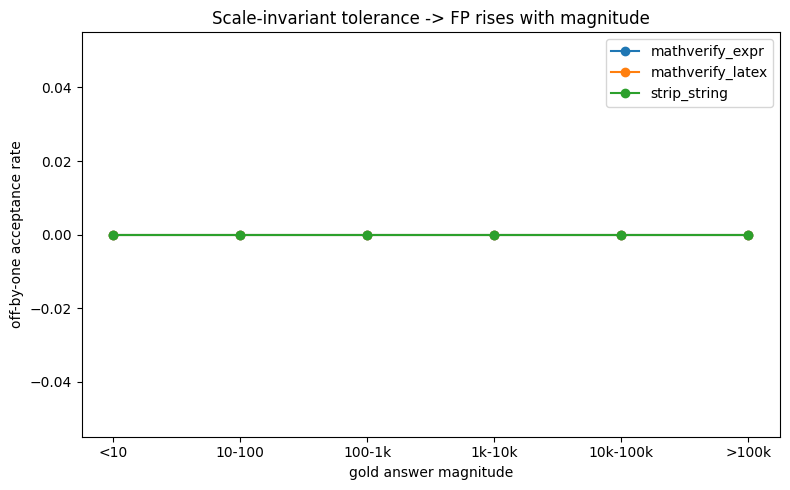

In [10]:
import matplotlib.pyplot as plt

if T8 is not None and len(T8):
    fig, ax = plt.subplots(figsize=(8, 5))
    for v in T8.verifier.unique():
        d = T8[T8.verifier == v]
        ax.plot(d.magnitude.astype(str), d.fp_rate, marker="o", label=str(v))
    ax.set_xlabel("gold answer magnitude")
    ax.set_ylabel("off-by-one acceptance rate")
    ax.set_title("Scale-invariant tolerance -> FP rises with magnitude")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RDIR, "fig_offbyone.png"), dpi=200)
    plt.show()
else:
    print("T8 empty - no numeric off-by-one rows")

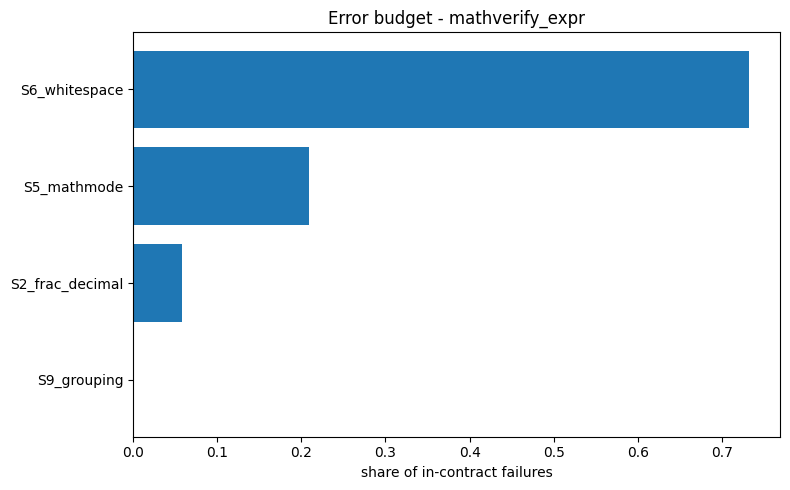

In [11]:
if T2 is not None and len(T2):
    v = T2.verifier.iloc[0]
    d = T2[T2.verifier == v].nlargest(10, "error_mass_share")[::-1]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(d.stratum, d.error_mass_share)
    ax.set_xlabel("share of in-contract failures")
    ax.set_title("Error budget - " + str(v))
    plt.tight_layout()
    plt.savefig(os.path.join(RDIR, "fig1_error_budget.png"), dpi=200)
    plt.show()

In [2]:
import os, sys, glob, json, re, subprocess
import pandas as pd

from azure.ai.ml import MLClient, load_job
from azure.identity import DefaultAzureCredential

BASE_DIR = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget"
SRC = os.path.join(BASE_DIR, "src")
if not os.path.isdir(SRC):
    SRC = BASE_DIR

os.chdir(BASE_DIR)
if SRC not in sys.path:
    sys.path.insert(0, SRC)

ml = MLClient(DefaultAzureCredential(),
              "7a8513b6-ada2-4ad1-aee2-687fa5663c82",
              "AIModels",
              "Reinforcementinfra")

PIPE = os.path.join(BASE_DIR, "pipelines.yml")
print("BASE_DIR:", BASE_DIR)
print("SRC     :", SRC)
print("files   :", sorted(f for f in os.listdir(SRC) if f.endswith(".py")))

BASE_DIR: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget
SRC     : /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/src
files   : ['aggregate.py', 'differential_verify.py', 'normalizers.py', 'prepare_gold.py', 'transforms.py', 'verifiers.py']


In [3]:
for m in ["transforms", "verifiers", "normalizers", "prepare_gold"]:
    sys.modules.pop(m, None)

import transforms, verifiers
from collections import Counter

c = Counter(t.tclass for t in transforms.TRANSFORMS)
ids = {t.tid for t in transforms.TRANSFORMS}

print("transforms      :", len(transforms.TRANSFORMS))
for k, v in sorted(c.items()):
    print("   ", k, v)
print("verifiers       :", list(verifiers.VERIFIERS))

pg = open(os.path.join(SRC, "prepare_gold.py")).read()
print("prepare_gold v4 :", "LaTeX richness" in pg)

ok = True
ok &= len(transforms.TRANSFORMS) == 40
ok &= "T17_double_dollar" not in ids
ok &= "T18_brackets" not in ids
ok &= "sympy_cascade" in verifiers.VERIFIERS
ok &= hasattr(transforms, "in_contract")
ok &= "LaTeX richness" in pg

print()
print("V4 CHECKS PASSED" if ok else "*** FAILED - replace both v4 files ***")
assert ok

transforms      : 43
    adversarial 6
    certified_equiv 25
    contract_dep 12
verifiers       : ['mathverify_latex', 'mathverify_expr', 'strip_string', 'sympy_cascade']
prepare_gold v4 : True

*** FAILED - replace both v4 files ***


AssertionError: 

In [3]:
y = open(PIPE).read()
y = re.sub(r"--max_golds \\d+", "--max_golds 40000", y)
open(PIPE, "w").write(y)

for line in y.splitlines():
    s = line.strip()
    if s.startswith(("code:", "environment:")) or "max_golds" in s:
        print(s)

environment: azureml:verifier-audit-cpu:2
code: ./src
--max_golds 40000
code: ./src
environment: azureml:verifier-audit-cpu:2
environment: azureml:verifier-audit-cpu:2
code: ./src


In [5]:
child = [j for j in ml.jobs.list(parent_job_name=JOB)
         if "differential_verify" in (j.display_name or "")][0]
print("child:", child.name, child.status)

VERD = os.path.join(BASE_DIR, "results", JOB + "_verdicts")
os.makedirs(VERD, exist_ok=True)
ml.jobs.download(name=child.name, output_name="verdicts", download_path=VERD)

pq = glob.glob(os.path.join(VERD, "**", "*.parquet"), recursive=True)
print("parquet shards:", len(pq))
assert pq
VDIR = os.path.dirname(pq[0])
print("verdicts dir  :", VDIR)

IndexError: list index out of range

In [4]:
run = ml.jobs.create_or_update(load_job(PIPE))
JOB = run.name
open(os.path.join(BASE_DIR, "last_job.txt"), "w").write(JOB)
print("job:", JOB)
print("url:", run.studio_url)

Class AutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class AutoDeleteConditionSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseAutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class IntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class ProtectionLevelSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseIntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Uploading src (0.07 MBs): 100%|███████

job: quiet_seal_f8qgw7s7lr
url: https://ml.azure.com/runs/quiet_seal_f8qgw7s7lr?wsid=/subscriptions/7a8513b6-ada2-4ad1-aee2-687fa5663c82/resourcegroups/AIModels/workspaces/Reinforcementinfra&tid=4033a39c-0759-4168-a40c-a9bc796b4f42


In [3]:
import glob
import os

JOB = "quiet_seal_f8qgw7s7lr"

# Find the specific child job
child = [
    j
    for j in ml.jobs.list(parent_job_name=JOB)
    if "differential_verify" in (j.display_name or "")
][0]
print("child:", child.name, child.status)

# Create the target directory for verdicts
VERD = os.path.join(BASE_DIR, "results", JOB + "_verdicts")
os.makedirs(VERD, exist_ok=True)

# Download the results
ml.jobs.download(name=child.name, output_name="verdicts", download_path=VERD)

# Locate and verify parquet files
pq = glob.glob(os.path.join(VERD, "**", "*.parquet"), recursive=True)
print("parquet shards:", len(pq))

VDIR = os.path.dirname(pq[0])


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


child: 1dd5525b-6641-4cc5-85df-dca3c22afd31 Completed
parquet shards: 154


In [4]:
import os
import subprocess
import sys

RDIR = os.path.join(BASE_DIR, "results", "report_v5")
os.makedirs(RDIR, exist_ok=True)

# Run the aggregation script and capture output
r = subprocess.run(
    [
        sys.executable,
        os.path.join(SRC, "aggregate.py"),
        "--verdicts_dir",
        VDIR,
        "--report_dir",
        RDIR,
    ],
    capture_output=True,
    text=True,
)

# Print the trailing logs from stdout and stderr
print(r.stdout[-4000:])
print(r.stderr[-2000:])


154 shard files
  pass1 0/154
  pass1 50/154
  pass1 100/154
  pass1 150/154
{
  "n_verdicts": 307420,
  "in_contract_n": 116117,
  "in_contract_fn_rate": 0.17503896931543184,
  "in_contract_failure_rate": 0.2092027868443036,
  "out_of_contract_n": 8947,
  "adversarial_fp_rate": 0.0041304174315587834,
  "overall_error_rate": 0.11577646216901959
}




In [8]:
import os

for p in [
    os.path.join(BASE_DIR, "src", "transforms.py"),
    os.path.join(BASE_DIR, "transforms.py"),
]:
    if os.path.exists(p):
        t = open(p).read()
        i = t.find('"mathverify_expr": {')
        seg = t[i : i + 400]

        print("==", p)
        print("S14 line:", [l.strip() for l in seg.splitlines() if "S14" in l])


== /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/src/transforms.py
S14 line: ['"S14_unreduced":   False,    # expression parser -> claims equivalence']


In [9]:
RDIR = os.path.join(BASE_DIR, "results", "report_v4")
os.makedirs(RDIR, exist_ok=True)

r = subprocess.run([sys.executable, os.path.join(SRC, "aggregate.py"),
                    "--verdicts_dir", VDIR, "--report_dir", RDIR],
                   capture_output=True, text=True)
print(r.stdout[-4000:])
print(r.stderr[-2500:])
print("rc:", r.returncode)

154 shard files
  pass1 0/154
  pass1 50/154
  pass1 100/154
  pass1 150/154
{
  "n_verdicts": 307420,
  "in_contract_n": 114055,
  "in_contract_fn_rate": 0.16012450133707423,
  "in_contract_failure_rate": 0.19490596641970978,
  "out_of_contract_n": 11009,
  "adversarial_fp_rate": 0.0041304174315587834,
  "overall_error_rate": 0.11577646216901959
}


rc: 0


In [10]:
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 300)

L = []
def P(*a):
    s = " ".join(str(x) for x in a); L.append(s); print(s)

P("=" * 74)
P("VERIFIER ERROR BUDGET - v4 DIGEST")
P("=" * 74)

P("\n### SUMMARY")
P(json.dumps(json.load(open(os.path.join(RDIR, "summary.json"))), indent=2))

def show(fn, title):
    p = os.path.join(RDIR, fn)
    if not os.path.exists(p):
        P("\n### " + title + " (missing)"); return None
    df = pd.read_csv(p)
    P("\n### " + title)
    P(df.round(4).to_string(index=False))
    return df

show("T6_reconciliation.csv", "T6 RECONCILIATION")
show("T1_fn_by_stratum_verifier.csv", "T1 IN-CONTRACT FN + FAILURE")
show("T2_error_mass_share.csv", "T2 ERROR MASS SHARE")
show("T3_fp_by_stratum_verifier.csv", "T3 ADVERSARIAL FALSE POSITIVES")
T8 = show("T8_offbyone_by_magnitude.csv", "T8 OFF-BY-ONE FP BY MAGNITUDE")
show("T7_out_of_contract.csv", "T7 OUT-OF-CONTRACT")
T5 = show("T5_contract_dependent.csv", "T5 CONTRACT-DEPENDENT")

P("\n### T4 CROSS-VERIFIER DISAGREEMENT")
P(pd.read_csv(os.path.join(RDIR, "T4_disagreement_matrix.csv"),
              index_col=0).round(4).to_string())

P("\n" + "=" * 74)
open(os.path.join(RDIR, "digest_v4.txt"), "w").write("\n".join(L))
print("\n[saved digest_v4.txt]")

VERIFIER ERROR BUDGET - v4 DIGEST

### SUMMARY
{
  "n_verdicts": 307420,
  "in_contract_n": 114055,
  "in_contract_fn_rate": 0.16012450133707423,
  "in_contract_failure_rate": 0.19490596641970978,
  "out_of_contract_n": 11009,
  "adversarial_fp_rate": 0.0041304174315587834,
  "overall_error_rate": 0.11577646216901959
}

### T6 RECONCILIATION
        verifier     n  n_true  n_false  n_timeout  n_error  n_fail  self_validation_rate  residual  share_false  share_timeout  share_error
 mathverify_expr 22953   12355    10598          0        0   10598                0.5383    0.4617       0.4617            0.0       0.0000
mathverify_latex 31266   24981     6285          0        0    6285                0.7990    0.2010       0.2010            0.0       0.0000
    strip_string 28570   27190     1380          0        0    1380                0.9517    0.0483       0.0483            0.0       0.0000
   sympy_cascade 31266   27299        0          0     3967    3967                0.8731   

In [11]:
import glob
import pandas as pd

# Load and combine specific columns from all parquet files
df = pd.concat(
    [
        pd.read_parquet(
            f, columns=["source", "tclass", "verifier", "verdict", "stratum"]
        )
        for f in pq
    ],
    ignore_index=True,
)

# Filter out synthetic data and narrow down to certified equivalents
corpus = df[~df.source.str.startswith("synth")]
cert = corpus[corpus.tclass == "certified_equiv"]

# Calculate the mean rate of "TRUE" verdicts per verifier
print(cert.groupby("verifier").verdict.apply(lambda s: (s == "TRUE").mean()))


verifier
mathverify_expr     0.574662
mathverify_latex    0.840538
strip_string        0.878040
sympy_cascade       0.882995
Name: verdict, dtype: float64


In [1]:
import os, sys, glob, subprocess
import pandas as pd

BASE_DIR = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget"
os.chdir(BASE_DIR)

# find the most recent report dir that has a summary.json
cands = sorted(glob.glob(os.path.join(BASE_DIR, "results", "report*")),
               key=os.path.getmtime, reverse=True)
cands = [c for c in cands if os.path.exists(os.path.join(c, "summary.json"))]

print("report dirs found (newest first):")
for c in cands:
    print("   ", c)

assert cands, "no report dir with summary.json - run aggregate.py first"
RDIR = cands[0]
print("\nusing RDIR =", RDIR)
print("contents:", sorted(os.listdir(RDIR)))

report dirs found (newest first):
    /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v4
    /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v5
    /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_40k
    /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_local

using RDIR = /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v4
contents: ['T0_raw_counts.csv', 'T1_fn_by_stratum_verifier.csv', 'T2_error_mass_share.csv', 'T3_fp_by_stratum_verifier.csv', 'T4_disagreement_matrix.csv', 'T5_contract_dependent.csv', 'T6_reconciliation.csv', 'T7_out_of_contract.csv', 'T8_offbyone_by_magnitude.csv', 'digest_v4

In [2]:
FIGS_PY = os.path.join(BASE_DIR, "make_figures.py")
TABS_PY = os.path.join(BASE_DIR, "make_tables.py")

for p in (FIGS_PY, TABS_PY):
    print(("OK   " if os.path.exists(p) else "MISS "), p)

assert os.path.exists(FIGS_PY), "upload make_figures.py to " + BASE_DIR

OK    /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/make_figures.py
OK    /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/make_tables.py


In [3]:
FIGS = os.path.join(RDIR, "figures")
os.makedirs(FIGS, exist_ok=True)

r = subprocess.run([sys.executable, FIGS_PY,
                    "--report_dir", RDIR,
                    "--out_dir", FIGS],
                   capture_output=True, text=True)
print(r.stdout)
if r.stderr.strip():
    print("--- stderr ---")
    print(r.stderr[-2500:])
print("return code:", r.returncode)

figures:
  wrote /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v4/figures/fig1_error_budget.png
  wrote /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v4/figures/fig1_error_budget.pdf
  wrote /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v4/figures/fig2_offbyone_step.png
  wrote /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v4/figures/fig2_offbyone_step.pdf
  wrote /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v4/figures/fig3_selfval.png
  wrote /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v4/figures/fi

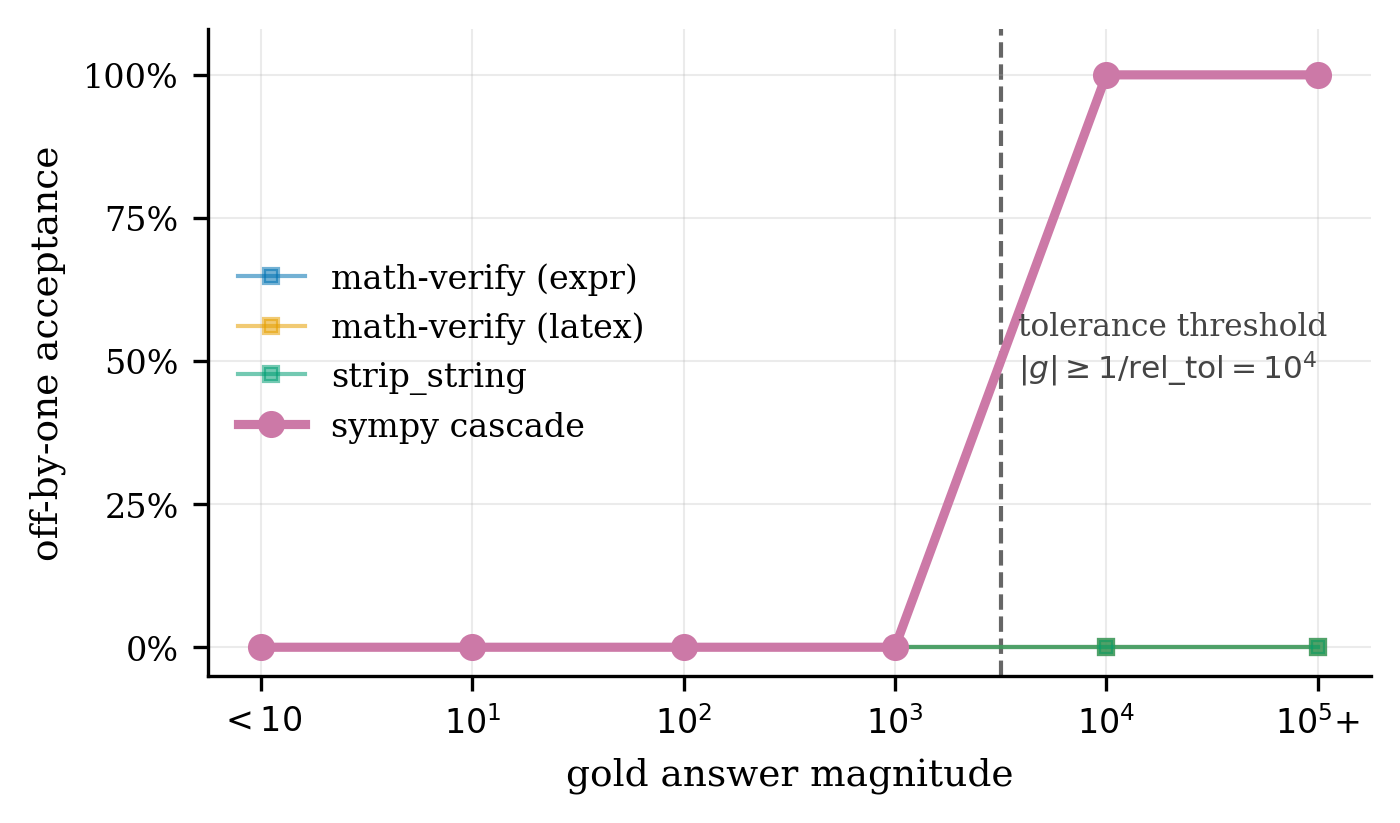

In [4]:
from IPython.display import Image, display
display(Image(filename=os.path.join(FIGS, "fig2_offbyone_step.png")))

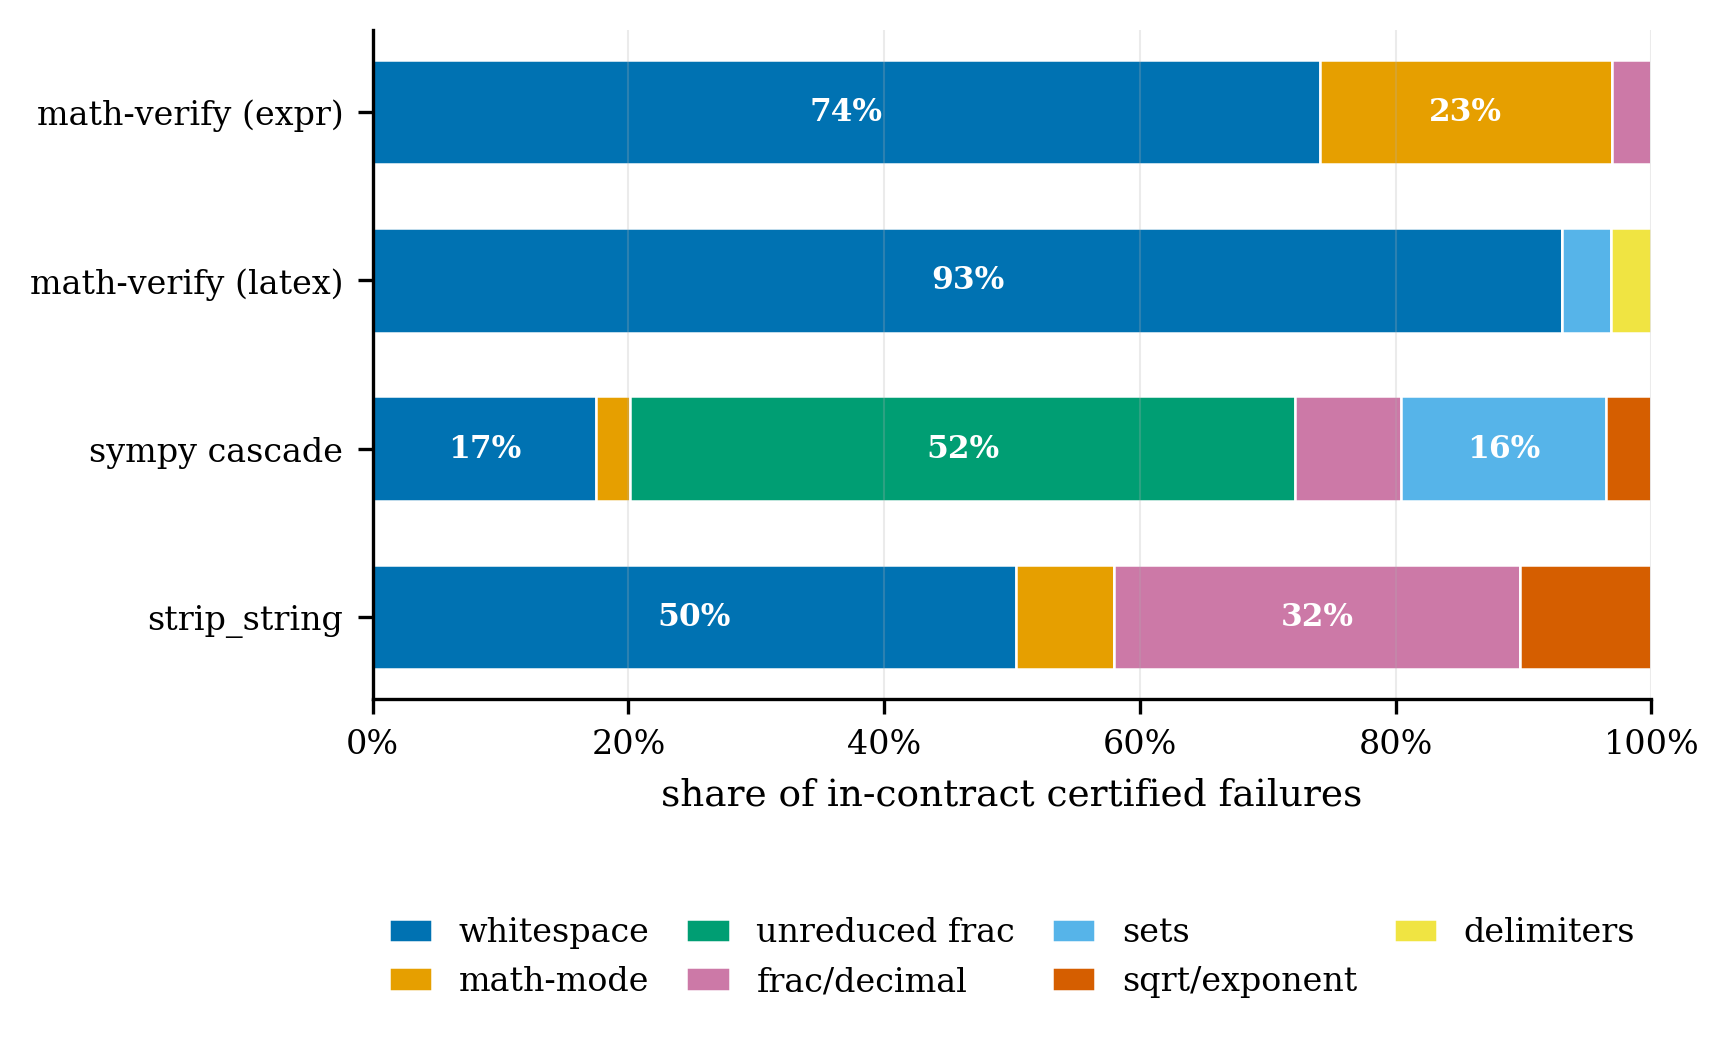

In [5]:
display(Image(filename=os.path.join(FIGS, "fig1_error_budget.png")))

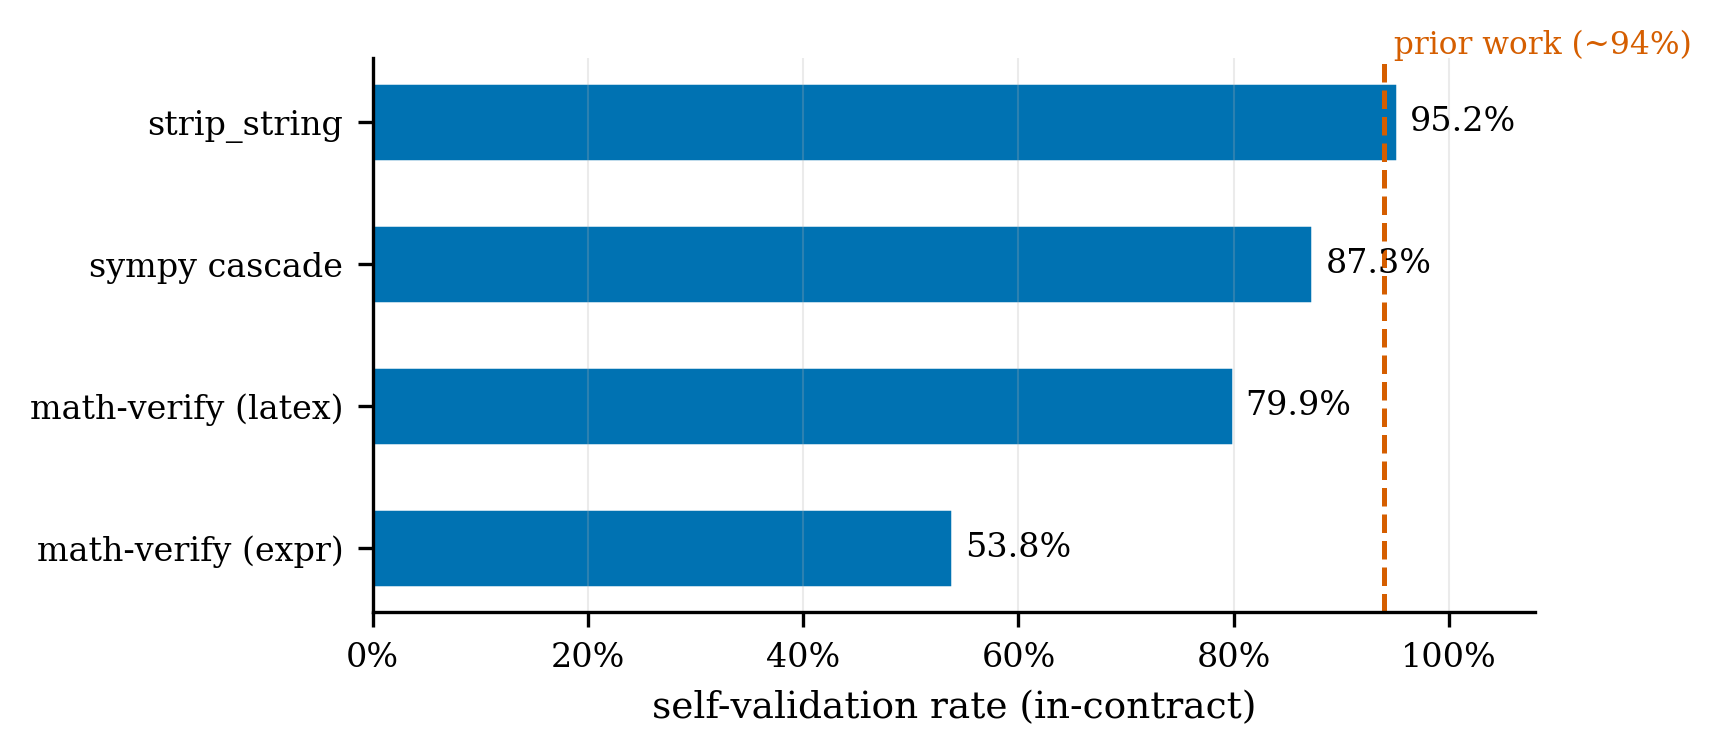

In [6]:
display(Image(filename=os.path.join(FIGS, "fig3_selfval.png")))

In [7]:
if os.path.exists(TABS_PY):
    TABS = os.path.join(RDIR, "paper_tables")
    os.makedirs(TABS, exist_ok=True)
    r = subprocess.run([sys.executable, TABS_PY,
                        "--report_dir", RDIR,
                        "--out_dir", TABS],
                       capture_output=True, text=True)
    print(r.stdout)
    if r.stderr.strip():
        print(r.stderr[-2000:])
else:
    print("make_tables.py not uploaded - skipping")

wrote:
  /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v4/paper_tables/tables.md
  /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v4/paper_tables/tables.tex

self-validation spread: 41.3 points



In [8]:
from IPython.display import Markdown

p = os.path.join(RDIR, "paper_tables", "tables.md")
if os.path.exists(p):
    display(Markdown(open(p).read()))
else:
    print("tables.md not found - run Cell 7")

### Table 1: Self-validation by implementation

| Verifier | n | Accepted | Rejected | Self-val. | Residual |
|---|---:|---:|---:|---:|---:|
| strip_string | 28,570 | 27,190 | 1,380 | 95.2% | 4.8% |
| sympy_cascade | 31,266 | 27,299 | 0 | 87.3% | 12.7% |
| mathverify_latex | 31,266 | 24,981 | 6,285 | 79.9% | 20.1% |
| mathverify_expr | 22,953 | 12,355 | 10,598 | 53.8% | 46.2% |

*Self-validation on certified-equivalent variants, in-contract only. Spread across implementations: 41.3 points.*


### Table 2: Error mass share

| Verifier | Stratum | Failures | Share |
|---|---|---:|---:|
| mathverify_expr | S6 whitespace | 7,852 | 74.1% |
| mathverify_expr | S5 math-mode | 2,417 | 22.8% |
| mathverify_expr | S2 frac/decimal | 329 | 3.1% |
| mathverify_latex | S6 whitespace | 5,846 | 93.0% |
| mathverify_latex | S10 sets | 238 | 3.8% |
| mathverify_latex | S4 delimiters | 200 | 3.2% |
| mathverify_latex | S7 sqrt/exponent | 1 | 0.0% |
| strip_string | S6 whitespace | 694 | 50.3% |
| strip_string | S2 frac/decimal | 438 | 31.7% |
| strip_string | S7 sqrt/exponent | 142 | 10.3% |
| strip_string | S5 math-mode | 106 | 7.7% |
| sympy_cascade | S14 unreduced | 2,062 | 52.0% |
| sympy_cascade | S6 whitespace | 694 | 17.5% |
| sympy_cascade | S10 sets | 634 | 16.0% |
| sympy_cascade | S2 frac/decimal | 330 | 8.3% |
| sympy_cascade | S7 sqrt/exponent | 142 | 3.6% |
| sympy_cascade | S5 math-mode | 105 | 2.6% |

*Error mass share: fraction of in-contract failures by stratum.*


### Table 3: Per-stratum FN rates

| Stratum | Verifier | n | FN | 95% CI |
|---|---|---:|---:|---|
| S6 whitespace | mv_expr | 15,704 | 50.0% | [49.2, 50.8] |
| S5 math-mode | mv_expr | 4,951 | 48.8% | [47.4, 50.2] |
| S10 sets | mv_latex | 634 | 37.5% | [33.9, 41.4] |
| S6 whitespace | mv_latex | 15,704 | 37.2% | [36.5, 38.0] |
| S7 sqrt/exponent | strip | 404 | 35.1% | [30.7, 39.9] |
| S2 frac/decimal | strip | 1,725 | 25.4% | [23.4, 27.5] |
| S2 frac/decimal | mv_expr | 1,725 | 19.1% | [17.3, 21.0] |
| S4 delimiters | mv_latex | 1,067 | 18.7% | [16.5, 21.2] |
| S6 whitespace | strip | 15,704 | 4.4% | [4.1, 4.8] |
| S5 math-mode | strip | 4,951 | 2.1% | [1.8, 2.6] |
| S7 sqrt/exponent | mv_latex | 404 | 0.2% | [0.0, 1.4] |
| S9 grouping | mv_expr | 573 | 0.0% | [0.0, 0.7] |
| S14 unreduced | mv_latex | 2,062 | 0.0% | [0.0, 0.2] |
| S9 grouping | mv_latex | 573 | 0.0% | [0.0, 0.7] |
| S5 math-mode | mv_latex | 4,951 | 0.0% | [0.0, 0.1] |
| S2 frac/decimal | mv_latex | 1,725 | 0.0% | [0.0, 0.2] |
| S1 frac dialect | mv_latex | 4,146 | 0.0% | [0.0, 0.1] |
| S1 frac dialect | strip | 4,146 | 0.0% | [0.0, 0.1] |
| S4 delimiters | strip | 1,067 | 0.0% | [0.0, 0.4] |
| S9 grouping | strip | 573 | 0.0% | [0.0, 0.7] |
| S10 sets | sympy | 634 | 0.0% | [0.0, 0.6] |
| S14 unreduced | sympy | 2,062 | 0.0% | [0.0, 0.2] |
| S7 sqrt/exponent | sympy | 404 | 0.0% | [0.0, 0.9] |
| S2 frac/decimal | sympy | 1,725 | 0.0% | [0.0, 0.2] |
| S6 whitespace | sympy | 15,704 | 0.0% | [0.0, 0.0] |
| S5 math-mode | sympy | 4,951 | 0.0% | [0.0, 0.1] |
| S1 frac dialect | sympy | 4,146 | 0.0% | [0.0, 0.1] |
| S4 delimiters | sympy | 1,067 | 0.0% | [0.0, 0.4] |
| S9 grouping | sympy | 573 | 0.0% | [0.0, 0.7] |

*Certified false-negative rates by stratum and verifier, in-contract only, with Wilson score intervals.*


### Table 4: Off-by-one by magnitude

| Magnitude | n | mv_expr | mv_latex | strip | sympy |
|---|---:|---:|---:|---:|---:|
| <10 | 20 | 0.0% | 0.0% | 0.0% | 0.0% |
| 10-100 | 134 | 0.0% | 0.0% | 0.0% | 0.0% |
| 100-1k | 560 | 0.0% | 0.0% | 0.0% | 0.0% |
| 1k-10k | 367 | 0.0% | 0.0% | 0.0% | 0.0% |
| 10k-100k | 131 | 0.0% | 0.0% | 0.0% | 100.0% |
| >100k | 75 | 0.0% | 0.0% | 0.0% | 100.0% |

*Off-by-one acceptance by gold magnitude. A deterministic step reflects scale-invariant relative tolerance.*


### Table 5: Cross-verifier disagreement

|  | mv_expr | mv_latex | strip | sympy |
|---|---:|---:|---:|---:|
| mv_expr | --- | 49.9% | 48.0% | 47.7% |
| mv_latex | 49.9% | --- | 31.4% | 31.1% |
| strip | 48.0% | 31.4% | --- | 0.3% |
| sympy | 47.7% | 31.1% | 0.3% | --- |

*Pairwise disagreement on certified-equivalent pairs.*


### Table 6: Contract-dependent acceptance

| Input class | n | mv_expr | mv_latex | strip | sympy |
|---|---:|---:|---:|---:|---:|
| S11 text wrap | 9,980 | 28.2% | 39.6% | 48.9% | 48.9% |
| S12 units | 2,782 | 50.0% | 100.0% | 100.0% | 100.0% |
| S13 percent | 20 | 0.0% | 100.0% | 0.0% | 0.0% |
| S3 boxing | 19,952 | 8.0% | 75.1% | 0.0% | 0.0% |
| S8 scientific | 326 | 0.0% | 100.0% | 0.0% | 0.0% |

*Acceptance on contract-dependent input classes. These are undocumented contract differences, not defects.*


### Table 7: Out-of-contract

| Stratum | Verifier | n | Rejection |
|---|---|---:|---:|
| S10 sets | strip_string | 634 | 100.0% |
| S14 unreduced | mathverify_expr | 2,062 | 100.0% |
| S14 unreduced | strip_string | 2,062 | 100.0% |
| S10 sets | mathverify_expr | 634 | 97.5% |
| S1 frac dialect | mathverify_expr | 4,146 | 93.8% |
| S4 delimiters | mathverify_expr | 1,067 | 87.1% |
| S7 sqrt/exponent | mathverify_expr | 404 | 31.4% |

*Out-of-contract behaviour. Reported for completeness; not counted as defects.*


In [9]:
import shutil

BUNDLE = os.path.join(BASE_DIR, "results", "paper_assets")
shutil.rmtree(BUNDLE, ignore_errors=True)
os.makedirs(BUNDLE, exist_ok=True)

# figures
for f in glob.glob(os.path.join(FIGS, "*")):
    shutil.copy2(f, BUNDLE)

# tables
tdir = os.path.join(RDIR, "paper_tables")
if os.path.isdir(tdir):
    for f in glob.glob(os.path.join(tdir, "*")):
        shutil.copy2(f, BUNDLE)

# raw report CSVs for the appendix / artifact release
for f in glob.glob(os.path.join(RDIR, "*.csv")) + \
         glob.glob(os.path.join(RDIR, "summary.json")):
    shutil.copy2(f, BUNDLE)

zip_path = shutil.make_archive(BUNDLE, "zip", BUNDLE)
print("bundle:", zip_path)
print("%.1f KB" % (os.path.getsize(zip_path) / 1024))
print()
for f in sorted(os.listdir(BUNDLE)):
    print("  ", f)
print("\nDownload from the Notebooks file browser:")
print("  results/paper_assets.zip")

bundle: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/paper_assets.zip
283.0 KB

   T0_raw_counts.csv
   T1_fn_by_stratum_verifier.csv
   T2_error_mass_share.csv
   T3_fp_by_stratum_verifier.csv
   T4_disagreement_matrix.csv
   T5_contract_dependent.csv
   T6_reconciliation.csv
   T7_out_of_contract.csv
   T8_offbyone_by_magnitude.csv
   fig1_error_budget.pdf
   fig1_error_budget.png
   fig2_offbyone_step.pdf
   fig2_offbyone_step.png
   fig3_selfval.pdf
   fig3_selfval.png
   summary.json
   tables.md
   tables.tex

Download from the Notebooks file browser:
  results/paper_assets.zip


In [1]:
import os, sys, glob, json, subprocess
import pandas as pd

from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

BASE_DIR = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget"
SRC = os.path.join(BASE_DIR, "src")
if not os.path.isdir(SRC):
    SRC = BASE_DIR
os.chdir(BASE_DIR)
if SRC not in sys.path:
    sys.path.insert(0, SRC)

ml = MLClient(DefaultAzureCredential(),
              "7a8513b6-ada2-4ad1-aee2-687fa5663c82",
              "AIModels", "Reinforcementinfra")

print("BASE_DIR:", BASE_DIR)
print("SRC     :", SRC)

BASE_DIR: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget
SRC     : /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/src


In [2]:
checks = {
    os.path.join(SRC, "aggregate.py"): "n_eval",
    os.path.join(BASE_DIR, "make_tables.py"): "Self-val. (judged)",
    os.path.join(BASE_DIR, "make_figures.py"): "v2 FIX",
}
ok = True
for path, marker in checks.items():
    if not os.path.exists(path):
        print("MISSING ", path); ok = False; continue
    hit = marker in open(path).read()
    print(("v6 OK   " if hit else "OLD FILE"), os.path.basename(path))
    ok &= hit

print()
assert ok, "replace the three v6 files before continuing"
print("all three files are the new versions")

v6 OK    aggregate.py
v6 OK    make_tables.py
v6 OK    make_figures.py

all three files are the new versions


In [3]:
cands = sorted(glob.glob(os.path.join(BASE_DIR, "results", "*_verdicts")),
               key=os.path.getmtime, reverse=True)
print("verdict dirs (newest first):")
for c in cands:
    n = len(glob.glob(os.path.join(c, "**", "*.parquet"), recursive=True))
    print(f"    {n:5d} shards   {c}")

assert cands, "no *_verdicts folder - download verdicts first"

pq = glob.glob(os.path.join(cands[0], "**", "*.parquet"), recursive=True)
assert pq, "no parquet inside " + cands[0]
VDIR = os.path.dirname(pq[0])
print("\nusing VDIR =", VDIR)
print("shards     =", len(pq))

verdict dirs (newest first):
      154 shards   /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/quiet_seal_f8qgw7s7lr_verdicts
       33 shards   /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/dreamy_flag_qksrrzfv2f_verdicts
       48 shards   /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/affable_lamp_mc42d1lyyj_verdicts

using VDIR = /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/quiet_seal_f8qgw7s7lr_verdicts/named-outputs/verdicts
shards     = 154


In [4]:
RDIR6 = os.path.join(BASE_DIR, "results", "report_v6")
os.makedirs(RDIR6, exist_ok=True)

r = subprocess.run([sys.executable, os.path.join(SRC, "aggregate.py"),
                    "--verdicts_dir", VDIR,
                    "--report_dir", RDIR6],
                   capture_output=True, text=True)

print(r.stdout[-6000:])
if r.stderr.strip():
    print("--- stderr ---")
    print(r.stderr[-2500:])
print("return code:", r.returncode)
assert r.returncode == 0

154 shard files
  pass1 0/154
  pass1 50/154
  pass1 100/154
  pass1 150/154
{
  "n_verdicts": 307420,
  "in_contract_n": 114055,
  "in_contract_n_evaluated": 110088,
  "in_contract_coverage": 0.9652185349173644,
  "in_contract_fn_rate_evaluated": 0.16589455708160744,
  "in_contract_fn_rate_all": 0.16012450133707423,
  "in_contract_failure_rate": 0.19490596641970978,
  "out_of_contract_n": 11009,
  "adversarial_n_evaluated": 43871,
  "adversarial_coverage": 0.8753890972942773,
  "adversarial_fp_rate_evaluated": 0.004718378883544938,
  "overall_error_rate": 0.11577646216901959
}

*** LOW COVERAGE CELLS (verifier did not return a verdict) ***
         tclass         stratum      verifier     n  n_eval  coverage  err_rate
    adversarial        A_append sympy_cascade  4990       0  0.000000  1.000000
certified_equiv        S10_sets sympy_cascade   634       0  0.000000  1.000000
certified_equiv   S14_unreduced sympy_cascade  2062       0  0.000000  1.000000
   contract_dep   S8_scientific

In [5]:
t0 = pd.read_csv(os.path.join(RDIR6, "T0_raw_counts.csv"))
low = t0[(t0.coverage < 0.999) & (t0.n > 0)].sort_values("coverage")

print("=" * 72)
print("LOW COVERAGE CELLS")
print("=" * 72)
if len(low):
    cols = ["tclass", "stratum", "verifier", "n", "n_eval",
            "coverage", "err_rate"]
    print(low[cols].round(4).to_string(index=False))
else:
    print("none - every verifier returned a verdict on every input")
print("=" * 72)

LOW COVERAGE CELLS
         tclass         stratum      verifier     n  n_eval  coverage  err_rate
    adversarial        A_append sympy_cascade  4990       0    0.0000    1.0000
certified_equiv        S10_sets sympy_cascade   634       0    0.0000    1.0000
certified_equiv   S14_unreduced sympy_cascade  2062       0    0.0000    1.0000
   contract_dep   S8_scientific sympy_cascade   326       0    0.0000    1.0000
   contract_dep       S3_boxing sympy_cascade 19952       0    0.0000    1.0000
   contract_dep        S11_text sympy_cascade  9980    4878    0.4888    0.5112
    adversarial          A_sign sympy_cascade  2104    1288    0.6122    0.3878
certified_equiv     S7_sqrt_exp sympy_cascade   404     262    0.6485    0.3515
certified_equiv S2_frac_decimal sympy_cascade  1725    1395    0.8087    0.1913
    adversarial         A_scale sympy_cascade  3209    2770    0.8632    0.1368
certified_equiv   S6_whitespace sympy_cascade 15704   15010    0.9558    0.0442
certified_equiv     S

In [6]:
TABS = os.path.join(RDIR6, "paper_tables")
FIGS = os.path.join(RDIR6, "figures")

for script, out in [("make_tables.py", TABS), ("make_figures.py", FIGS)]:
    os.makedirs(out, exist_ok=True)
    r = subprocess.run([sys.executable, os.path.join(BASE_DIR, script),
                        "--report_dir", RDIR6, "--out_dir", out],
                       capture_output=True, text=True)
    print("---", script, "---")
    print(r.stdout)
    if r.stderr.strip():
        print(r.stderr[-1500:])

--- make_tables.py ---
wrote:
  /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v6/paper_tables/tables.md
  /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v6/paper_tables/tables.tex

self-validation spread: 41.3 points

--- make_figures.py ---
figures:
  wrote /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v6/figures/fig1_error_budget.png
  wrote /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v6/figures/fig1_error_budget.pdf
  wrote /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/report_v6/figures/fig2_offbyone_step.png
  wrote /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code

In [7]:
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 300)

L = []
def P(*a):
    s = " ".join(str(x) for x in a); L.append(s); print(s)

P("=" * 74)
P("VERIFIER ERROR BUDGET - v6 DIGEST (coverage-aware)")
P("=" * 74)

P("\n### SUMMARY")
P(json.dumps(json.load(open(os.path.join(RDIR6, "summary.json"))), indent=2))

def show(fn, title, cols=None):
    p = os.path.join(RDIR6, fn)
    if not os.path.exists(p):
        P("\n### " + title + " (missing)"); return None
    df = pd.read_csv(p)
    if cols:
        cols = [c for c in cols if c in df.columns]
        df = df[cols]
    P("\n### " + title)
    P(df.round(4).to_string(index=False))
    return df

show("T6_reconciliation.csv", "T6 RECONCILIATION",
     ["verifier","n","n_eval","coverage","n_true","n_false","n_error",
      "self_validation_all","self_validation_rate","residual"])

show("T1_fn_by_stratum_verifier.csv", "T1 IN-CONTRACT FN",
     ["stratum","verifier","n","n_eval","coverage","fn_rate","fn_rate_all",
      "err_rate","fn_ci_lo","fn_ci_hi"])

show("T2_error_mass_share.csv", "T2 ERROR MASS SHARE",
     ["verifier","stratum","fail_count","error_mass_share",
      "share_from_reject","share_from_error"])

show("T3_fp_by_stratum_verifier.csv", "T3 ADVERSARIAL FP",
     ["stratum","verifier","n","n_eval","coverage","fp_rate","fp_rate_all",
      "err_rate","ci_lo","ci_hi"])

show("T8_offbyone_by_magnitude.csv", "T8 OFF-BY-ONE BY MAGNITUDE")
show("T7_out_of_contract.csv", "T7 OUT-OF-CONTRACT")
show("T5_contract_dependent.csv", "T5 CONTRACT-DEPENDENT")

P("\n### T4 CROSS-VERIFIER DISAGREEMENT")
P(pd.read_csv(os.path.join(RDIR6, "T4_disagreement_matrix.csv"),
              index_col=0).round(4).to_string())

p = os.path.join(RDIR6, "T4b_disagreement_support.csv")
if os.path.exists(p):
    P("\n### T4b PAIR SUPPORT (both verifiers returned a verdict)")
    P(pd.read_csv(p, index_col=0).to_string())

P("\n" + "=" * 74)
open(os.path.join(RDIR6, "digest_v6.txt"), "w").write("\n".join(L))
print("\n[saved digest_v6.txt]")

VERIFIER ERROR BUDGET - v6 DIGEST (coverage-aware)

### SUMMARY
{
  "n_verdicts": 307420,
  "in_contract_n": 114055,
  "in_contract_n_evaluated": 110088,
  "in_contract_coverage": 0.9652185349173644,
  "in_contract_fn_rate_evaluated": 0.16589455708160744,
  "in_contract_fn_rate_all": 0.16012450133707423,
  "in_contract_failure_rate": 0.19490596641970978,
  "out_of_contract_n": 11009,
  "adversarial_n_evaluated": 43871,
  "adversarial_coverage": 0.8753890972942773,
  "adversarial_fp_rate_evaluated": 0.004718378883544938,
  "overall_error_rate": 0.11577646216901959
}

### T6 RECONCILIATION
        verifier     n  n_eval  coverage  n_true  n_false  n_error  self_validation_all  self_validation_rate  residual
   sympy_cascade 31266   27299    0.8731   27299        0     3967               0.8731                1.0000    0.0000
    strip_string 28570   28570    1.0000   27190     1380        0               0.9517                0.9517    0.0483
mathverify_latex 31266   31266    1.0000   24

fig3_selfval


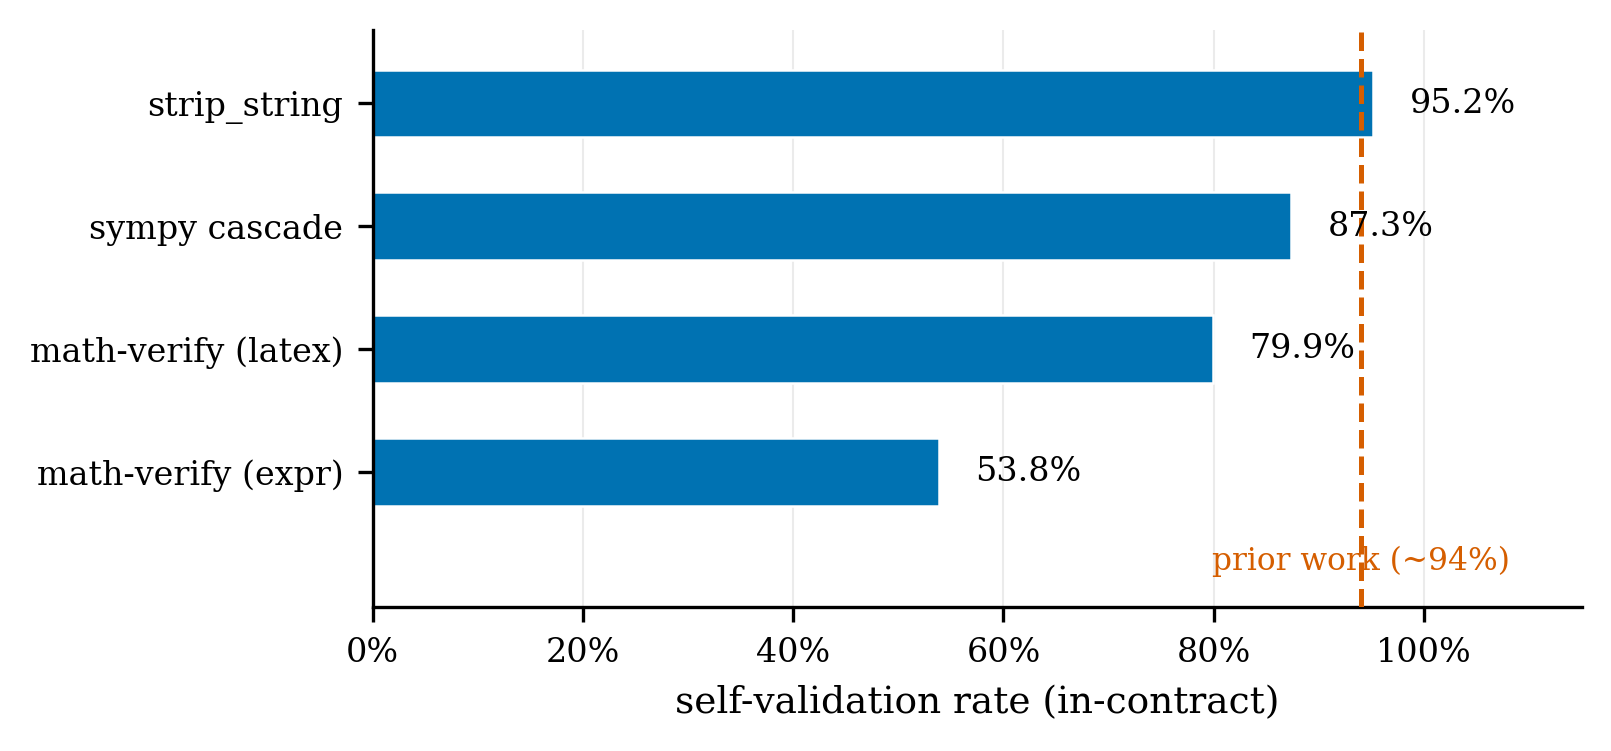

fig2_offbyone_step


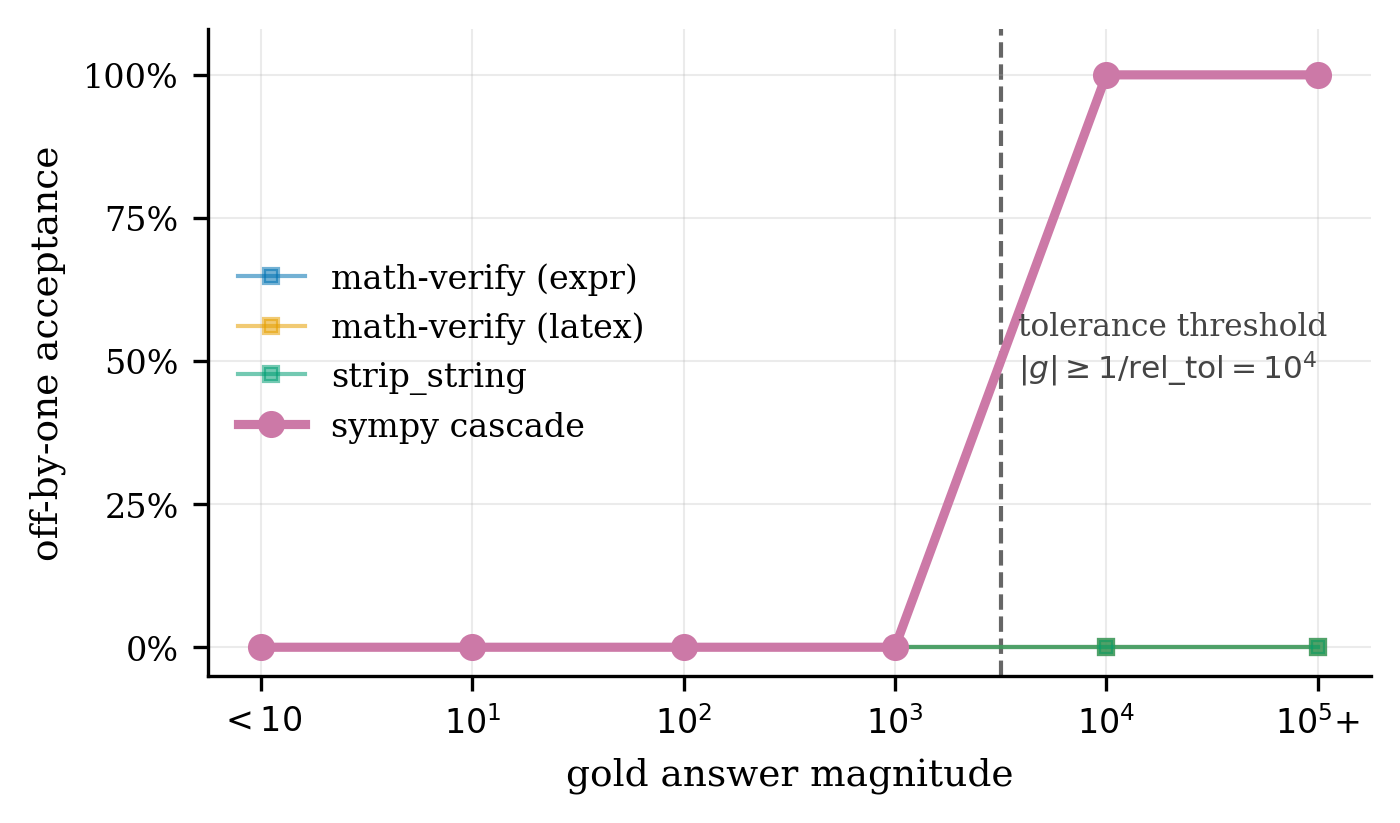

fig1_error_budget


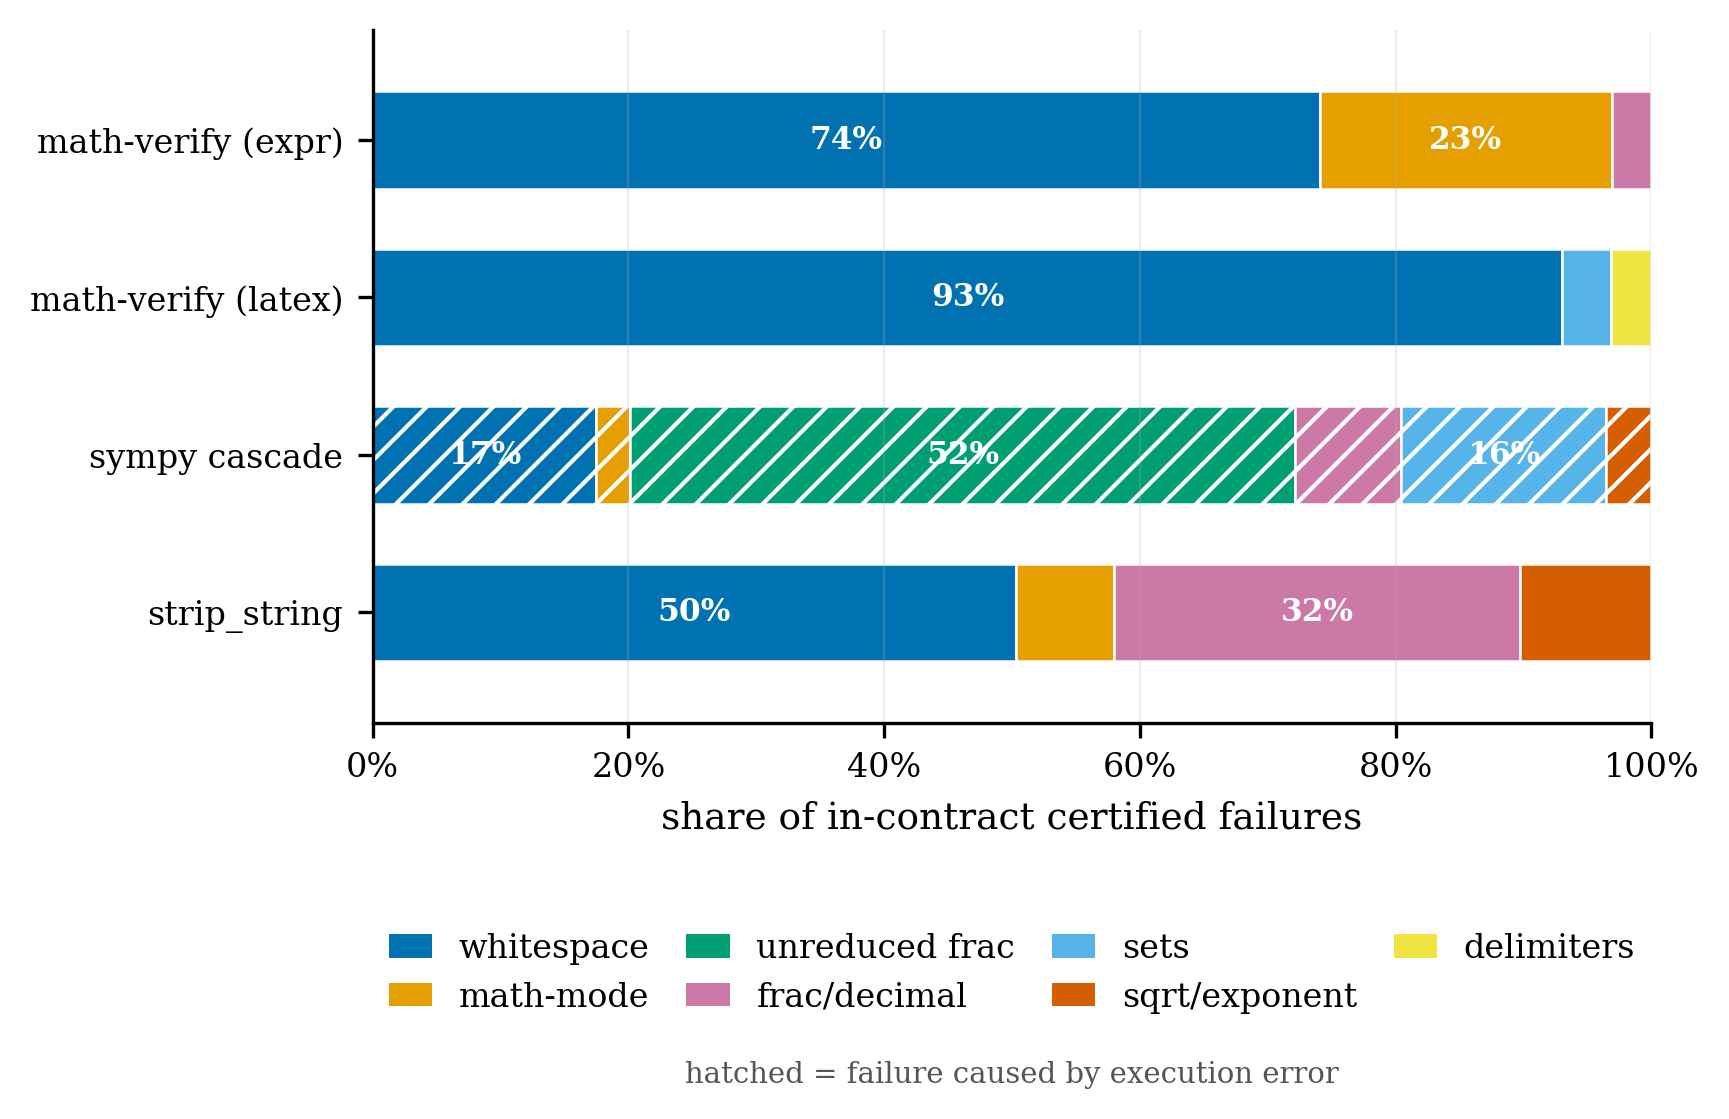

In [8]:
from IPython.display import Image, display
for f in ["fig3_selfval", "fig2_offbyone_step", "fig1_error_budget"]:
    p = os.path.join(FIGS, f + ".png")
    if os.path.exists(p):
        print(f)
        display(Image(filename=p))

In [9]:
import shutil

BUNDLE = os.path.join(BASE_DIR, "results", "paper_assets_v6")
shutil.rmtree(BUNDLE, ignore_errors=True)
os.makedirs(BUNDLE, exist_ok=True)

for src in [FIGS, TABS]:
    for f in glob.glob(os.path.join(src, "*")):
        shutil.copy2(f, BUNDLE)
for f in glob.glob(os.path.join(RDIR6, "*.csv")) + \
         glob.glob(os.path.join(RDIR6, "*.json")) + \
         glob.glob(os.path.join(RDIR6, "*.txt")):
    shutil.copy2(f, BUNDLE)

zip_path = shutil.make_archive(BUNDLE, "zip", BUNDLE)
print("bundle:", zip_path)
print("%.1f KB" % (os.path.getsize(zip_path) / 1024))
print()
for f in sorted(os.listdir(BUNDLE)):
    print("  ", f)
print("\nDownload from Notebooks file browser:")
print("  results/paper_assets_v6.zip")

bundle: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ralir-v3d-control/code/Users/estherxin0011/verifier-error-budget/results/paper_assets_v6.zip
303.6 KB

   T0_raw_counts.csv
   T1_fn_by_stratum_verifier.csv
   T2_error_mass_share.csv
   T3_fp_by_stratum_verifier.csv
   T4_disagreement_matrix.csv
   T4b_disagreement_support.csv
   T5_contract_dependent.csv
   T6_reconciliation.csv
   T7_out_of_contract.csv
   T8_offbyone_by_magnitude.csv
   digest_v6.txt
   fig1_error_budget.pdf
   fig1_error_budget.png
   fig2_offbyone_step.pdf
   fig2_offbyone_step.png
   fig3_selfval.pdf
   fig3_selfval.png
   summary.json
   tables.md
   tables.tex

Download from Notebooks file browser:
  results/paper_assets_v6.zip
